# 03 Pretraining Practice：预训练实践

> 前置：`05-deep-learning-architectures/05-gpt-language-models`（GPT 结构）、`01-tokenization`、`02-scaling-laws`。
> 目标：把"小 GPT"推到更接近真实的预训练设置——更大语料、训练/验证划分、困惑度指标、学习率与过拟合观察。

## 预训练是什么

在大规模纯文本上做**自监督**：给定前 $t$ 个 token，预测第 $t+1$ 个。损失即交叉熵。衡量指标：

$$\text{Perplexity}(\text{PPL}) = \exp(\mathcal{L}_{\text{val}})$$

PPL 的直觉：模型在每个位置对"正确 token"给出的平均概率的倒数——**PPL=2 意味着模型平均给正确 token 50% 概率**。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import math, time
import matplotlib

matplotlib.rcParams["font.sans-serif"] = ["PingFang SC", "Hiragino Sans GB", "Arial Unicode MS", "Microsoft YaHei", "sans-serif"]
matplotlib.rcParams["axes.unicode_minus"] = False

print("PyTorch version:", torch.__version__)
torch.manual_seed(42)


PyTorch version: 2.13.0


In [2]:
class CharTokenizer:
    """字符级分词器：LLM 的最小原型。"""
    def __init__(self, text):
        self.chars = sorted(set(text))
        self.stoi = {c: i for i, c in enumerate(self.chars)}
        self.itos = {i: c for i, c in enumerate(self.chars)}
        self.vocab_size = len(self.chars)
    def encode(self, s):
        return [self.stoi[c] for c in s]
    def decode(self, ids):
        return "".join(self.itos[i] for i in ids)

class MHA(nn.Module):
    def __init__(self, d=32, n_heads=4):
        super().__init__()
        assert d % n_heads == 0
        self.dk = d // n_heads; self.n_heads = n_heads
        self.Wq = nn.Linear(d, d); self.Wk = nn.Linear(d, d)
        self.Wv = nn.Linear(d, d); self.Wo = nn.Linear(d, d)
        self.register_buffer("mask", torch.triu(torch.ones(512, 512), diagonal=1).bool())
    def forward(self, x):
        B, T, d = x.shape
        q = self.Wq(x).view(B, T, self.n_heads, self.dk).transpose(1, 2)
        k = self.Wk(x).view(B, T, self.n_heads, self.dk).transpose(1, 2)
        v = self.Wv(x).view(B, T, self.n_heads, self.dk).transpose(1, 2)
        scores = q @ k.transpose(-2, -1) / math.sqrt(self.dk)
        scores = scores.masked_fill(self.mask[:T, :T], float("-inf"))
        attn = torch.softmax(scores, dim=-1)
        return self.Wo((attn @ v).transpose(1, 2).contiguous().view(B, T, d))

class Block(nn.Module):
    def __init__(self, d=32, n_heads=4, d_ff=64):
        super().__init__()
        self.norm1 = nn.LayerNorm(d); self.attn = MHA(d, n_heads)
        self.norm2 = nn.LayerNorm(d)
        self.ff = nn.Sequential(nn.Linear(d, d_ff), nn.ReLU(), nn.Linear(d_ff, d))
    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        return x + self.ff(self.norm2(x))

class TinyGPT(nn.Module):
    def __init__(self, vocab, d=32, n_heads=4, d_ff=64, n_layers=2, max_t=128):
        super().__init__()
        self.tok = nn.Embedding(vocab, d)
        self.pos = nn.Parameter(torch.randn(max_t, d) * 0.02)
        self.blocks = nn.ModuleList([Block(d, n_heads, d_ff) for _ in range(n_layers)])
        self.norm = nn.LayerNorm(d)
        self.head = nn.Linear(d, vocab)
    def forward(self, idx):
        B, T = idx.shape
        x = self.tok(idx) + self.pos[:T]
        for b in self.blocks:
            x = b(x)
        return self.head(self.norm(x))

def count_params(m):
    return sum(p.numel() for p in m.parameters())

def make_corpus(seed=0, length=40000, style="default"):
    """生成有结构的合成语料（字符级）。style='reversed' 时词序倒装。"""
    rng = np.random.default_rng(seed)
    subjects = ["cat", "dog", "bird", "fox"]
    verbs = ["sat", "ran", "sang", "jumped"]
    places = ["mat", "park", "tree", "fence"]
    text = ""
    while len(text) < length:
        s = "the " + rng.choice(subjects) + " " + rng.choice(verbs) + " on the " + rng.choice(places)
        if style == "reversed":
            s = " ".join(reversed(s.split()))
        text += s + " "
    return text[:length]

def train_gpt(model, ids, steps=500, batch=64, seq=32, lr=3e-3, val_ids=None, log_every=100):
    """标准训练循环，返回 (steps, train_loss) 列表。"""
    opt = torch.optim.AdamW(model.parameters(), lr=lr)
    n = len(ids) - seq - 1
    curve = []
    for step in range(steps):
        i = torch.randint(0, n, (batch,))
        x = torch.stack([ids[j:j + seq] for j in i])
        y = torch.stack([ids[j + 1:j + seq + 1] for j in i])
        opt.zero_grad()
        loss = F.cross_entropy(model(x).reshape(-1, model.head.out_features), y.reshape(-1))
        loss.backward(); opt.step()
        if step % log_every == 0 or step == steps - 1:
            curve.append((step, loss.item()))
            if val_ids is not None and step % (log_every * 5) == 0:
                with torch.no_grad():
                    vi = torch.randint(0, len(val_ids) - seq - 1, (64,))
                    vx = torch.stack([val_ids[j:j + seq] for j in vi])
                    vy = torch.stack([val_ids[j + 1:j + seq + 1] for j in vi])
                    vl = F.cross_entropy(model(vx).reshape(-1, model.head.out_features), vy.reshape(-1)).item()
                print(f"step {step:4d}  train={loss.item():.4f}  val={vl:.4f}")
            else:
                print(f"step {step:4d}  train={loss.item():.4f}")
    return curve

@torch.no_grad()
def generate(model, tok, prompt, n=80, temp=0.8):
    ids = tok.encode(prompt)
    idx = torch.tensor([ids], dtype=torch.long)
    for _ in range(n):
        logits = model(idx[:, -64:])
        probs = torch.softmax(logits[:, -1, :] / temp, dim=-1)
        nxt = torch.multinomial(probs, 1)
        idx = torch.cat([idx, nxt], dim=1)
    return tok.decode(idx[0].tolist())


## 语料与设置

- 语料：60k 字符，两种句式的混合语法（体现"多样但不无限"的真实感）；
- 划分：90% 训练 / 10% 验证——**验证集永远不参与梯度更新**；
- 模型：`d=48, 3 层, 4 头`（约 15 万参数，比上一课大一号），`seq=48`。

In [3]:
rng = np.random.default_rng(0)
def make_rich_corpus(seed=0, length=60000):
    rng = np.random.default_rng(seed)
    subjects = ["cat", "dog", "bird", "fox"]
    verbs = ["sat", "ran", "sang", "jumped"]
    places = ["mat", "park", "tree", "fence"]
    text = ""
    while len(text) < length:
        if rng.random() < 0.7:
            s = "the " + rng.choice(subjects) + " " + rng.choice(verbs) + " on the " + rng.choice(places)
        else:
            s = "a " + rng.choice(subjects) + " " + rng.choice(verbs) + " near the " + rng.choice(places)
        text += s + " "
    return text[:length]

corpus = make_rich_corpus()
tok = CharTokenizer(corpus)
ids = torch.tensor(tok.encode(corpus), dtype=torch.long)
split = int(len(ids) * 0.9)
train_ids, val_ids = ids[:split], ids[split:]
print(f"词表={tok.vocab_size}  总字符={len(ids)}  训练={len(train_ids)}  验证={len(val_ids)}")
print("语料开头:", tok.decode(ids[:80].tolist()))

词表=21  总字符=60000  训练=54000  验证=6000
语料开头: the bird ran on the park the cat sat on the fence a bird sang near the fence the


## 训练

用小学习率 + AdamW（真实预训练标配），记录训练与验证损失。观察两条曲线**分叉**——分叉点之后模型开始记忆训练集（过拟合），这正是早停的依据。

In [4]:
torch.manual_seed(0)
model = TinyGPT(tok.vocab_size, d=48, n_heads=4, d_ff=96, n_layers=3, max_t=64)
print("参数量:", count_params(model))

opt = torch.optim.AdamW(model.parameters(), lr=1e-3)
seq = 48
n = len(train_ids) - seq - 1
train_curve, val_curve = [], []
for step in range(1200):
    i = torch.randint(0, n, (64,))
    x = torch.stack([train_ids[j:j + seq] for j in i])
    y = torch.stack([train_ids[j + 1:j + seq + 1] for j in i])
    opt.zero_grad()
    loss = F.cross_entropy(model(x).reshape(-1, tok.vocab_size), y.reshape(-1))
    loss.backward(); opt.step()
    if step % 100 == 0:
        train_curve.append((step, loss.item()))
        with torch.no_grad():
            vi = torch.randint(0, len(val_ids) - seq - 1, (128,))
            vx = torch.stack([val_ids[j:j + seq] for j in vi])
            vy = torch.stack([val_ids[j + 1:j + seq + 1] for j in vi])
            vl = F.cross_entropy(model(vx).reshape(-1, tok.vocab_size), vy.reshape(-1)).item()
        val_curve.append((step, vl))
        print(f"step {step:4d}  train={loss.item():.4f}  val={vl:.4f}")

参数量: 62085


step    0  train=3.1659  val=2.9675


step  100  train=0.8548  val=0.8558


step  200  train=0.4158  val=0.4494


step  300  train=0.3076  val=0.3168


...

step  700  train=0.2394  val=0.2348


step  800  train=0.2372  val=0.2300


step  900  train=0.2290  val=0.2416


step 1000  train=0.2274  val=0.2306


step 1100  train=0.2386  val=0.2279


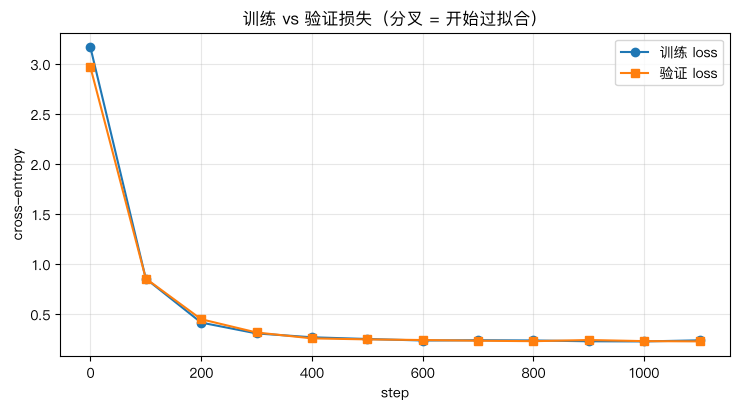

最终验证 PPL = 1.256  （exp(0.2279)）
含义：模型在每个位置给正确 token 的平均概率 ≈ 79.6%


In [5]:
st = [s for s, _ in train_curve]
plt.figure(figsize=(7.5, 4.2))
plt.plot(st, [l for _, l in train_curve], "o-", label="训练 loss")
plt.plot(st, [l for _, l in val_curve], "s-", label="验证 loss")
plt.xlabel("step"); plt.ylabel("cross-entropy")
plt.title("训练 vs 验证损失（分叉 = 开始过拟合）")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

ppl = math.exp(val_curve[-1][1])
print(f"最终验证 PPL = {ppl:.3f}  （exp({val_curve[-1][1]:.4f})）")
print("含义：模型在每个位置给正确 token 的平均概率 ≈ %.1f%%" % (100 / ppl))

In [6]:
print("预训练模型生成（温度 0.8）:")
print(repr(generate(model, tok, "the cat", n=90, temp=0.8)))
print()
print("温度 0.3（更保守）:")
print(repr(generate(model, tok, "a dog", n=90, temp=0.3)))

预训练模型生成（温度 0.8）:
'the cat jumped on the mat a fox sat near the tree the fe fence the fox ca sat ox ran on on thee t'

温度 0.3（更保守）:
'a dog sang near the tree the cat sang on the tree the fe bird can ox on on the pare the tre the'


## 总结：真实预训练的放大版

| 本课（玩具） | 真实 LLM |
|---|---|
| 60k 字符合成语料 | 数万亿 token 互联网文本 |
| 15 万参数 | 数十亿~数万亿参数 |
| 1200 步 | 数百万步（多轮 epoch） |
| 单机 CPU | 数千 GPU，混合精度 + 分布式 |
| 观察过拟合 | 同样观察（因此有数据配比/权重衰减） |

**核心不变**：自监督 next-token 预测 + 交叉熵 + 训练/验证划分 + PPL 评估。学懂这套流程，就学懂了 GPT 预训练的全部骨架。

## 课后练习

1. 把 `seq` 从 48 提到 96（同语料），观察训练/验证曲线变化——长上下文是"更多信息还是更多过拟合"？
2. 把学习率从 1e-3 提到 5e-3，观察震荡与最终 PPL——体会"预训练用稳学习率"。
3. 自己加一个余弦退火或线性 warmup 调度，对比固定学习率的验证 PPL。